#this a program that analyze how the earth is flat
ts bs pmo

In [2]:
data = [92, 45, 78, 12, 88, 64, 31, 97, 53, 22, 75, 81, 49, 10, 66, 94, 38, 57, 72, 85]

In [ ]:
import numpy as np

grades = np.array(data)

print(grades * 2) 


[184  90 156  24 176 128  62 194 106  44 150 162  98  20 132 188  76 114
 144 170]


In [4]:
grades.shape

(20,)

In [6]:
grades[4]

np.int64(88)

In [7]:
grades.mean()

np.float64(60.45)

In [9]:
study_hours = [
    10.0, 11.5, 9.0, 16.0, 9.25, 1.0, 11.5, 9.0, 8.5, 14.5, 15.5,
    13.75, 9.0, 8.0, 15.5, 8.0, 9.0, 6.0, 10.0, 12.0
]
student_data = np.array([study_hours, grades])

In [16]:
avg_study = student_data[0].mean()
avg_grade = student_data[1].mean()

print(f'average study time: {avg_study}\nAverage Grade: {avg_grade}')

average study time: 10.35
Average Grade: 60.45


In [21]:
import pandas as pd

df_students = pd.DataFrame({
    'name': [
        'Dan', 'Joann', 'Pedro', 'Rossie', 'Ethan', 
        'Sophia', 'Liam', 'Olivia', 'Noah', 'Ava', 
        'Lucas', 'Mia', 'Benjamin', 'Isabella', 'Mason', 
        'Amelia', 'Logan', 'Charlotte', 'James', 'Harper'
    ],
    'StudyHours' : student_data[0],
    'Grade' : student_data[1]
})

df_students

,name,StudyHours,Grade
0,Dan,10.00,92.0
1,Joann,11.50,45.0
2,Pedro,9.00,78.0
3,Rossie,16.00,12.0
4,Ethan,9.25,88.0
5,Sophia,1.00,64.0
6,Liam,11.50,31.0
7,Olivia,9.00,97.0
8,Noah,8.50,53.0
9,Ava,14.50,22.0


In [22]:
df_students.loc[0]

name           Dan
StudyHours    10.0
Grade         92.0
Name: 0, dtype: object

In [23]:
df_students[df_students['name'] == 'Dan']

,name,StudyHours,Grade
0,Dan,10.0,92.0


In [ ]:
import pandas as pd

# Define the direct link to the data
url = "https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/grades.csv"
 
# Read the data directly from the URL
df_students = pd.read_csv(url, delimiter=',', header='infer')

# Show the first 5 rows to confirm it works
df_students.head()

,Name,StudyHours,Grade
0,Dan,10.00,50.0
1,Joann,11.50,50.0
2,Pedro,9.00,47.0
3,Rosie,16.00,97.0
4,Ethan,9.25,49.0


In [15]:
student_data[1][3]

np.float64(12.0)

In [26]:
#if i really wanted to download

import urllib.request

# The link to the file
url = "https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/grades.csv"

# The name you want the file to have on your computer
filename = "grades.csv"

# This actually downloads and saves the file to your folder
urllib.request.urlretrieve(url, filename)

print(f"{filename} has been downloaded and should appear in your Explorer!")

grades.csv has been downloaded and should appear in your Explorer!


In [30]:
df_students.isnull().sum()

Name          0
StudyHours    0
Grade         0
dtype: int64

In [28]:
df_students.StudyHours = df_students.StudyHours.fillna(df_students.StudyHours.mean())

In [29]:
df_students = df_students.dropna(axis = 0)

In [32]:
mean_study = df_students['StudyHours'].mean()

mean_grade = df_students.Grade.mean()

print(f'average study time: {mean_study}\nAverage Grade: {mean_grade}')

average study time: 10.522727272727273
Average Grade: 49.18181818181818


In [33]:
df_students[df_students.StudyHours > mean_study]

,Name,StudyHours,Grade
1,Joann,11.50,50.0
3,Rosie,16.00,97.0
6,Frederic,11.50,53.0
9,Giovanni,14.50,74.0
10,Francesca,15.50,82.0
11,Rajab,13.75,62.0
14,Jenny,15.50,70.0
19,Skye,12.00,52.0
20,Daniel,12.50,63.0
21,Aisha,12.00,64.0


In [34]:
df_students[df_students.StudyHours > mean_study].Grade.mean()

np.float64(66.7)

In [35]:
import pandas as pd

passed = pd.Series(df_students.Grade >= 60)
df_students = pd.concat([df_students, passed.rename('passsed')], axis=1)

In [38]:
df_students.groupby(df_students.passsed).count()

,Name,StudyHours,Grade
passsed,,,
False,15,15,15
True,7,7,7


In [40]:
print(df_students.groupby(df_students.passsed).Grade.mean())

passsed
False    38.000000
True     73.142857
Name: Grade, dtype: float64


In [46]:
df_students.groupby('passsed')[['StudyHours', 'Grade']].mean()

,StudyHours,Grade
passsed,,
False,8.783333,38.000000
True,14.250000,73.142857


In [ ]:
df_students = df_students.sort_values('Grade', ascending = False)
#false gunanya untuk sorti terbalik

In [ ]:
#contoh dari awal sampe akhir
import pandas as pd
import urllib.request

# 1. Load data from a text file (Windows-friendly way)
url = "https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/grades.csv"
filename = "grades.csv"
urllib.request.urlretrieve(url, filename)

df_students = pd.read_csv('grades.csv', delimiter=',', header='infer')

# 2. Remove any rows with missing data
df_students = df_students.dropna(axis=0, how='any')

# 3. Calculate who passed, assuming '60' is the grade needed to pass
passes = pd.Series(df_students['Grade'] >= 60)

# 4. Save who passed to the Pandas dataframe (Concatenate)
df_students = pd.concat([df_students, passes.rename("Pass")], axis=1)

# 5. Print the result out into this notebook
df_students

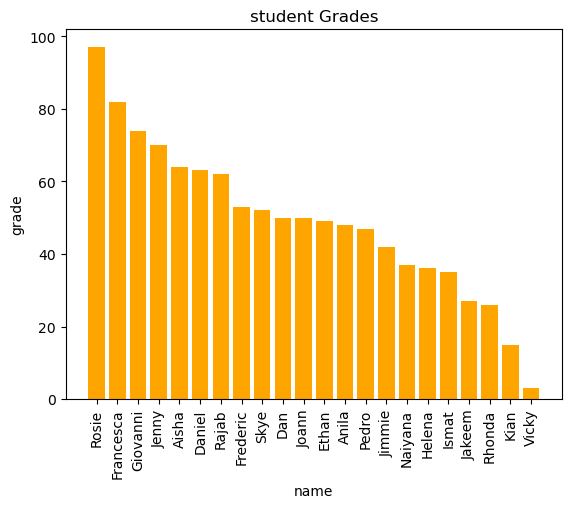

In [54]:
from matplotlib import pyplot as plt

plt.bar(x=df_students.Name, height = df_students.Grade, color="orange")

plt.title("student Grades")
plt.xlabel("name")
plt.ylabel("grade")
plt.xticks(rotation=90)

plt.show()

C:\Users\debor\AppData\Local\Temp\ipykernel_31968\3267972122.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


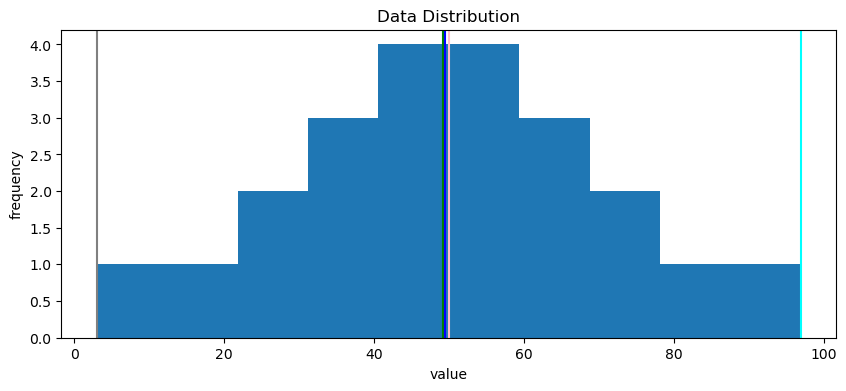

In [57]:
grades = df_students.Grade

min_val = df_students.Grade.min()
max_val = df_students.Grade.max()
mean_val = df_students.Grade.mean()
med_val = df_students.Grade.median()
mode_val = df_students.Grade.mode()[0]

fig = plt.figure(figsize=(10,4))

plt.hist(grades)

plt.axvline(x=min_val, color='gray')
plt.axvline(x=max_val, color='cyan')
plt.axvline(x=mean_val, color='green')
plt.axvline(x=med_val, color='blue')
plt.axvline(x=mode_val, color='pink')

plt.title("Data Distribution")
plt.xlabel("value")
plt.ylabel("frequency")

fig.show()

AttributeError: Figure.show works only for figures managed by pyplot, normally created by pyplot.figure()

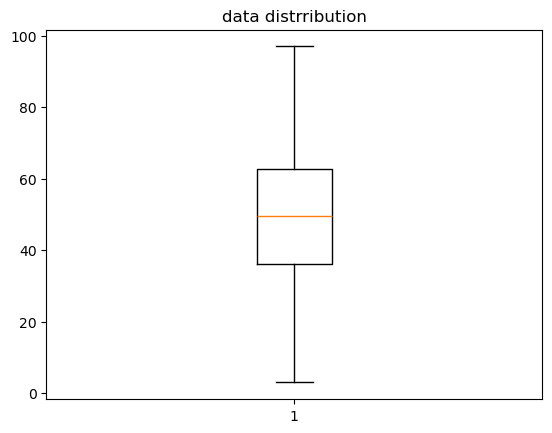

In [59]:
grades = df_students.Grade

fig = plt.Figure(figsize=(10, 4))

plt.boxplot(grades)

plt.title("data distrribution")

fig.show()

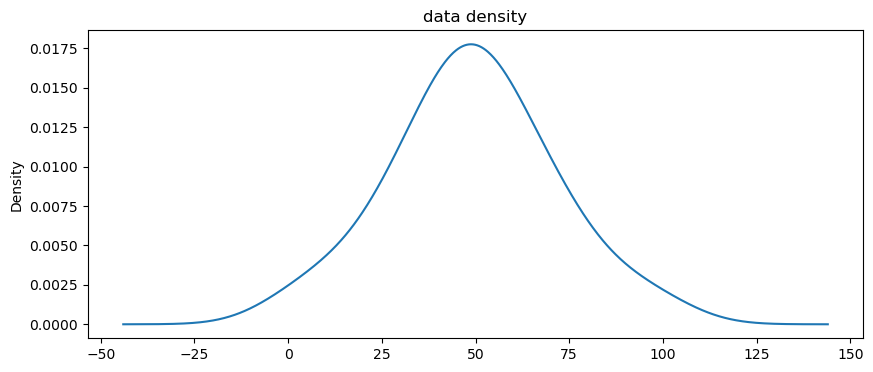

In [61]:
def show_density(data):
    fig = plt.figure(figsize=(10, 4))

    data.plot.density()

    plt.title("data density")

    plt.show()

show_density(df_students.Grade)